In [1]:
import drjit as dr
import xdesign as xd
import cupy as xp
import matplotlib.pyplot as plt
from pathlib import Path
import torch as th
import torch as th
from drjit.cuda.ad import Array2f, Array1f, ArrayXf, Float, TensorXf
import numpy as np

device = th.device("cuda:0" if th.cuda.is_available() else "cpu")

import sys
sys.path.append("src")
import xrt_toolkit as xtk

import sys
import numpy
numpy.set_printoptions(threshold=sys.maxsize)

Loaded weights from gpu_3D_spline_weights_drjit.npz.


In [2]:
def set_operators_parallel_beam_dr(N_side, N_angle, N_offset, pitch, angles, t_offset):
    angles = Float(angles)
    A, T = dr.meshgrid(angles, t_offset, indexing='ij')  
    M = N_angle * N_offset
    A = dr.reshape(A, shape=(-1,))
    T = dr.reshape(T, shape=(-1,))
    c = dr.cos(A)
    s = dr.sin(A)
    
    n_spec = Array2f(c, s) 
    t_unit = Array2f(s, c) * Array2f(-1.0, 1.0)

    t_spec = t_unit * T + pitch * N_side / 2 -0.5 -[0., 0.]

    return t_spec, n_spec

In [3]:
class XRT(dr.CustomOp):
    def eval(self, t_spec_dr, n_spec_dr, knot_spec, order, x, v_shape):
        # Stash everything we need for the backward pass
        self.t_spec_dr = t_spec_dr
        self.n_spec_dr = n_spec_dr
        self.knot_spec = knot_spec
        self.order = order
        self.x = x

        ray_spec = (t_spec_dr, n_spec_dr)
        return xtk.xrt_apply(ray_spec, knot_spec, order, x)

    def forward(self):
        raise RuntimeError("XRT: forward-mode differentiation not implemented")

    def backward(self):
        grad_x = xtk.xrt_adjoint((self.t_spec_dr, self.n_spec_dr), self.knot_spec, self.order, self.grad_out())
        self.set_grad_in('x', grad_x) 

        grad_t = dr.zeros(Array2f, self.t_spec_dr.shape)
        P_x = xtk.xrt_ad_t_x((self.t_spec_dr, self.n_spec_dr),
                         self.knot_spec, self.order, self.x)
        P_y = xtk.xrt_ad_t_y((self.t_spec_dr, self.n_spec_dr),
                            self.knot_spec, self.order, self.x)

        grad_t_x = self.grad_out() * P_x   # (num_offsets,)
        grad_t_y = self.grad_out() * P_y   # (num_offsets,)
        grad_t[0, :] = grad_t_x
        grad_t[1, :] = grad_t_y
        self.set_grad_in('t_spec_dr', grad_t)


        grad_n = dr.zeros(Array2f, self.n_spec_dr.shape)
        P_x = xtk.xrt_ad_n_x((self.t_spec_dr, self.n_spec_dr),
                           self.knot_spec, self.order, self.x)
        P_y = xtk.xrt_ad_n_y((self.t_spec_dr, self.n_spec_dr),
                           self.knot_spec, self.order, self.x)
        grad_n_x = self.grad_out() * P_x   # (num_offsets,)
        grad_n_y = self.grad_out() * P_y   # (num_offsets,)
        grad_n[0, :] = grad_n_x
        grad_n[1, :] = grad_n_y
        self.set_grad_in('n_spec_dr', grad_n)

    def name(self):
        return "xrt"


In [4]:
v_shape = (80,80)
x = np.random.rand(v_shape[0], v_shape[1]).astype(np.float32)
order = 0
x_dr = Float(x.reshape(-1))
knot_spec = xtk.UniformSpec(start=0, step=(1, 1), num=(v_shape[0], v_shape[1]))

# theta = th.pi/2 - th.pi/16
# t_spec = Array2f([[0.7],[-0.5]])
# n_spec = Array2f([[np.cos(theta)],[np.sin(theta)]])

# y_dr = xtk.xrt_apply((t_spec, n_spec), knot_spec, order, x_dr)

In [5]:
# fig = xtk.plot_rays((t_spec, n_spec), knot_spec, show_grid=True)
# fig.show()

### ---------- Harder test with all angles and offsets ---------------

In [6]:
n_angles = 10
n_offset = 1
# theta = th.tensor([th.pi/2 + th.pi/8])
offsets = th.tensor([0.45])
theta = th.linspace(0, th.pi, n_angles)
# offsets = th.linspace(-1.0, 1.0, 4)[0]

angles_ad = Float(theta)
dr.enable_grad(angles_ad)
t_ad, n_ad = set_operators_parallel_beam_dr(
        N_side=v_shape[0],
        N_angle=n_angles,
        N_offset=n_offset,
        pitch=1.0,
        angles=angles_ad,
        t_offset = Float(offsets)
    )

angles_custom = Float(theta)
dr.enable_grad(angles_custom)
t_custom, n_custom = set_operators_parallel_beam_dr(
        N_side=v_shape[0],
        N_angle=n_angles,
        N_offset=n_offset,
        pitch=1.0,
        angles=angles_custom,
        t_offset = Float(offsets)
    )

In [7]:
dr.enable_grad(n_custom)

In [8]:
x_custom = dr.copy(x_dr)
x_ad = dr.copy(x_dr)

y = dr.custom(XRT, t_custom, n_custom, knot_spec, order, x_custom, v_shape)
dr.backward(y)
r = xtk.xrt_apply((t_ad, n_ad), knot_spec, order, x_ad)
dr.backward(r)

delta = 1e-3
ux = Array2f([[1],[0]])
uy = Array2f([[0],[1]])
finite_diff_grad_n0 = (xtk.xrt_apply((t_ad, n_ad + delta * ux), knot_spec, order, x_dr) - xtk.xrt_apply((t_ad, n_ad), knot_spec, order, x_dr))/delta
finite_diff_grad_n1 = (xtk.xrt_apply((t_ad, n_ad + delta * uy), knot_spec, order, x_dr) - xtk.xrt_apply((t_ad, n_ad), knot_spec, order, x_dr))/delta

angles_ad_grad = np.asarray(angles_ad.grad)
angles_custom_grad = np.asarray(angles_custom.grad)
n_ad_grad = np.asarray(n_ad.grad)
n_custom_grad = np.asarray(n_custom.grad)
dr.eval()

print("-------- Angle gradients -----------")
print("(AD) nabla_ang:\n", angles_ad_grad)
print("(custom) nabla_ang:\n", angles_custom_grad)
print("max abs diff angles:", np.max(np.abs(angles_ad_grad - angles_custom_grad)))
print("-------- direction gradients -----------")
# print("(AD) nabla_n:\n", n_ad_grad)
print("(custom) nabla_n:\n", n_custom_grad)
print("(Finite-diff) nabla_n:\n", np.asarray(finite_diff_grad_n0),'\n',np.asarray(finite_diff_grad_n1))

-------- Angle gradients -----------
(AD) nabla_ang:
 [ 0.0000000e+00 -5.9628849e+01  2.4076917e+02 -3.2960330e+02
  3.4177433e+01  2.3192050e+02  2.5800232e+02  2.8151123e+02
 -2.9400760e+02  2.2852528e-06]
(custom) nabla_ang:
 [ 0.0000000e+00 -7.4330147e+01  2.4076945e+02 -3.2960324e+02
  3.4177334e+01  2.3192039e+02  2.8379462e+02  2.8151123e+02
 -2.8581650e+02  3.3518049e-06]
max abs diff angles: 25.792297
-------- direction gradients -----------
(custom) nabla_n:
 [[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]]
(Finite-diff) nabla_n:
 [   0.         20.381926 -156.39876   200.08467  -107.16247  -237.7548
 -224.3347   -186.01225    95.912926    0.      ] 
 [ 7.6293941e-03 -1.1776733e+02  1.4991377e+02 -1.6475294e+02
  5.8937068e+00 -4.0252682e+01 -1.2892912e+02 -2.1599959e+02
  1.7333983e+02  1.5258788e-02]


In [9]:
print('costheta/sintheta:', np.cos(theta)/np.sin(theta))
print('sintheta/costheta:', np.sin(theta)/np.cos(theta))
print('(costheta/sintheta)^2:', (np.cos(theta)/np.sin(theta))**2)
print('(sintheta/costheta)^2:', (np.sin(theta)/np.cos(theta))**2)

costheta/sintheta: tensor([        inf,  2.7475e+00,  1.1918e+00,  5.7735e-01,  1.7633e-01,
        -1.7633e-01, -5.7735e-01, -1.1918e+00, -2.7475e+00,  1.1439e+07])
sintheta/costheta: tensor([ 0.0000e+00,  3.6397e-01,  8.3910e-01,  1.7321e+00,  5.6713e+00,
        -5.6713e+00, -1.7321e+00, -8.3910e-01, -3.6397e-01,  8.7423e-08])
(costheta/sintheta)^2: tensor([       inf, 7.5486e+00, 1.4203e+00, 3.3333e-01, 3.1091e-02, 3.1091e-02,
        3.3333e-01, 1.4203e+00, 7.5486e+00, 1.3084e+14])
(sintheta/costheta)^2: tensor([0.0000e+00, 1.3247e-01, 7.0409e-01, 3.0000e+00, 3.2163e+01, 3.2163e+01,
        3.0000e+00, 7.0409e-01, 1.3247e-01, 7.6427e-15])


/tmp/ipykernel_59583/2987976450.py:1: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  print('costheta/sintheta:', np.cos(theta)/np.sin(theta))
/tmp/ipykernel_59583/2987976450.py:2: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  print('sintheta/costheta:', np.sin(theta)/np.cos(theta))
/tmp/ipykernel_59583/2987976450.py:3: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  print('(costheta/sintheta)^2:', (np.cos(theta)/np.sin(theta))**2)
/tmp/ipykernel_59583/2987976450.py:4: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  print('(sintheta/costheta)^2:', (np.sin(theta)/np.cos(theta))**2)


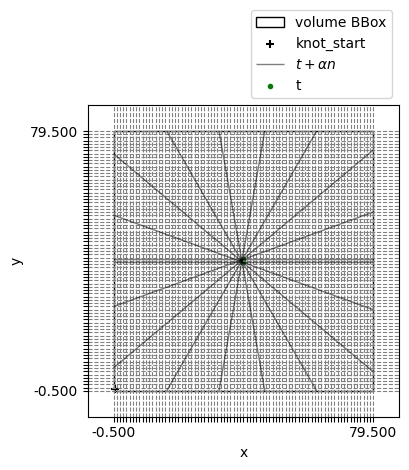

In [10]:
fig = xtk.plot_rays((t_ad, n_ad), knot_spec, show_grid=True)
fig.show()

In [11]:
# delta = 1e-5
# ux = Array2f([[1],[0]])
# uy = Array2f([[0],[1]])
# finite_diff_grad_t0 = (xtk.xrt_apply((t_ad + delta * ux, n_ad), knot_spec, order, x_dr) - xtk.xrt_apply((t_ad, n_ad), knot_spec, order, x_dr))/delta
# finite_diff_grad_t1 = (xtk.xrt_apply((t_ad + delta * uy, n_ad), knot_spec, order, x_dr) - xtk.xrt_apply((t_ad, n_ad), knot_spec, order, x_dr))/delta
# finite_diff_grad_n0 = (xtk.xrt_apply((t_ad, n_ad + delta * ux), knot_spec, order, x_dr) - xtk.xrt_apply((t_ad, n_ad), knot_spec, order, x_dr))/delta
# finite_diff_grad_n1 = (xtk.xrt_apply((t_ad, n_ad + delta * uy), knot_spec, order, x_dr) - xtk.xrt_apply((t_ad, n_ad), knot_spec, order, x_dr))/delta

# print("Finite difference nabla_t (ux):\n", ([finite_diff_grad_t0, finite_diff_grad_t1]))
# print("(custom) nabla_t:\n", np.asarray(t_custom.grad))
# print("(AD) nabla_t:\n", np.asarray(t_ad.grad))
# print("Finite difference nabla_n (ux):\n", ([finite_diff_grad_n0, finite_diff_grad_n1]))
# print("(custom) nabla_n:\n", np.asarray(n_custom.grad))
# print("(AD) nabla_n:\n", np.asarray(n_ad.grad))


# print("------------------------------")
# print("Difference nabla_x:", dr.norm(x_custom.grad - x_ad.grad))
# print("Difference nabla_t:", np.asarray(dr.norm(t_custom.grad - t_ad.grad)).round(3))
# print("Difference nabla_n:", np.asarray(dr.norm(n_custom.grad - n_ad.grad)).round(3))
# print(np.max(np.asarray(dr.abs(t_custom.grad - t_ad.grad)).round(3)))

# plt.figure()
# plt.plot(np.asarray(t_custom.grad)[0], label='custom grad t', alpha=0.3)
# plt.plot(np.asarray(t_ad.grad)[0], label='AD grad t')
# plt.legend()
# plt.show()

# plt.figure()
# plt.plot(np.asarray(t_custom.grad)[1], label='custom grad t')
# plt.plot(np.asarray(t_ad.grad)[1], label='AD grad t', alpha=0.3)
# plt.legend()
# plt.show()

# plt.figure()
# plt.plot(np.asarray(dr.norm(t_custom.grad - t_ad.grad)).round(3))
# plt.title("Difference nabla_t")
# plt.show()